In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, skew, kurtosis

In [2]:
# Loading Topsoil and Subsoil analysis results as excel files
Topdf = pd.read_excel('TopSoil_Compiled EDXFR Results_Orginal.xlsx')
Subdf = pd.read_excel('SubSoil_Compiled EDXFR Results_Orginal.xlsx')

In [3]:
Topdf.describe()

,Lab. No,Lab Sample #,Latitude,Longitude,Elev(m),dES(km),dES(m),dRD(m),0.01M CaCl2 (pH),Fe (mg/kg),Cu (mg/kg),Zn (mg/kg),Cd (mg/kg),As (mg/kg),Pb (mg/kg),Hg (mg/kg),OM
count,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.0,63.000000
mean,1871.111111,52.015873,-12.532276,28.223265,1275.523810,0.869675,869.675209,65.051429,6.436508,21891.269841,3777.730159,68.777778,14.809524,0.365079,18.396825,0.0,2.207838
std,29.834009,29.952377,0.002551,0.004440,7.594262,0.398495,398.494560,32.500825,0.844394,8535.051163,4328.653531,40.675920,5.123813,1.734857,9.652911,0.0,1.039337
min,1820.000000,1.000000,-12.537500,28.215111,1254.000000,0.156491,156.490527,2.740000,4.700000,8940.000000,198.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.359000
25%,1846.000000,27.000000,-12.534028,28.219667,1270.000000,0.558639,558.639063,35.555000,5.850000,14150.000000,1075.000000,46.500000,15.000000,0.000000,13.000000,0.0,1.571000
50%,1871.000000,52.000000,-12.532333,28.223556,1276.000000,0.849169,849.169072,79.950000,6.600000,21500.000000,2320.000000,56.000000,16.000000,0.000000,17.000000,0.0,1.983700
75%,1896.500000,77.500000,-12.530444,28.226736,1280.000000,1.165309,1165.308511,88.640000,7.100000,28350.000000,3855.000000,73.500000,17.000000,0.000000,21.500000,0.0,2.412450
max,1923.000000,104.000000,-12.526944,28.231583,1297.000000,1.652163,1652.163333,136.000000,8.000000,40100.000000,25700.000000,187.000000,19.000000,11.000000,47.000000,0.0,5.709300


In [4]:
# Dropping columns that are not needed
Topdf = Topdf.drop(columns=['Lab. No', 'Field No', 'Horizon Cm', 'Lab Sample #'])
# renaming the pH column
Topdf = Topdf.rename(columns={'0.01M CaCl2 (pH)': 'pH'})
Topdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    63 non-null     float64
 1   Longitude   63 non-null     float64
 2   Elev(m)     63 non-null     int64  
 3   dES(km)     63 non-null     float64
 4   dES(m)      63 non-null     float64
 5   dRD(m)      63 non-null     float64
 6   pH          63 non-null     float64
 7   Fe (mg/kg)  63 non-null     float64
 8   Cu (mg/kg)  63 non-null     float64
 9   Zn (mg/kg)  63 non-null     float64
 10  Cd (mg/kg)  63 non-null     float64
 11  As (mg/kg)  63 non-null     int64  
 12  Pb (mg/kg)  63 non-null     float64
 13  Hg (mg/kg)  63 non-null     int64  
 14  OM          63 non-null     float64
dtypes: float64(12), int64(3)
memory usage: 7.5 KB


## Shapiro-Wilk Normality test

### 1. Top Surface 

### 1.1. Top Soil Properites

In [5]:
# Specify which columns (Soil properties) to analyze
columns_to_analyze = ['pH', 'OM'] 

# Prepare list for table
table_rows = []

for soilproperty in columns_to_analyze:
    if soilproperty in Topdf.columns:
        values = Topdf[soilproperty].dropna()  # remove missing values if any
        W, p = shapiro(values)
        sk = skew(values, bias=False)
        kt = kurtosis(values, fisher=False, bias=False)
        if (abs(sk) <= 1) and (2 <= kt <= 4):
            distribution_shape = "Approximately normal (by skewness/kurtosis)"
        else:
            distribution_shape = "Non-normal (by skewness/kurtosis)"
        interpretation = "Consistent with normality" if p >= 0.05 else "Not normally distributed"
        
        table_rows.append({
            "Element": soilproperty,
            "Shapiro–Wilk W": round(W, 3),
            "p-value": "<0.001" if p < 0.001 else round(p, 3),
            "Skewness": round(sk, 2),
            "Kurtosis": round(kt, 2),
            "Normality Interpretation": interpretation,
        })
    else:
        print(f"Warning: Column '{soilproperty}' not found in file.")

# Create DataFrame
df_spT = pd.DataFrame(table_rows)

# Display table
print("Markdown Table:\n")
print(df_spT.to_markdown(index=False))

print("\nLaTeX Table:\n")
print(df_spT.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))

Markdown Table:

| Element   |   Shapiro–Wilk W | p-value   |   Skewness |   Kurtosis | Normality Interpretation   |
|:----------|-----------------:|:----------|-----------:|-----------:|:---------------------------|
| pH        |            0.965 | 0.069     |      -0.35 |       2.23 | Consistent with normality  |
| OM        |            0.888 | <0.001    |       1.37 |       5.37 | Not normally distributed   |

LaTeX Table:

\begin{table}
\centering
\caption{Shapiro–Wilk test results for selected elements}
\label{tab:shapiro_results}
\begin{tabular}{lrlrrl}
\toprule
Element &  Shapiro–Wilk W & p-value &  Skewness &  Kurtosis &  Normality Interpretation \\
\midrule
     pH &           0.965 &   0.069 &     -0.35 &      2.23 & Consistent with normality \\
     OM &           0.888 &  <0.001 &      1.37 &      5.37 &  Not normally distributed \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_9838/2396747360.py:38: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_spT.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))


### 1.2. Topsoil PTEs

In [6]:
# Specify which columns (elements) to analyze
columns_to_analyze = ['As (mg/kg)', 'Cd (mg/kg)', 'Pb (mg/kg)', 'Zn (mg/kg)', 'Cu (mg/kg)', 'Fe (mg/kg)']

# Prepare list for table
table_rows = []

for element in columns_to_analyze:
    if element in Topdf.columns:
        values = Topdf[element].dropna()  # remove missing values
        W, p = shapiro(values)
        sk = skew(values, bias=False)
        kt = kurtosis(values, fisher=False, bias=False)
        if (abs(sk) <= 1) and (2 <= kt <= 4):
            distribution_shape = "Approximately normal (by skewness/kurtosis)"
        else:
            distribution_shape = "Non-normal (by skewness/kurtosis)"
        interpretation = "Not significantly different from normal" if p >= 0.05 else "Not normally distributed"
        
        table_rows.append({
            "Element": element,
            "Shapiro–Wilk W": round(W, 3),
            "p-value": "<0.001" if p < 0.001 else round(p, 3),
            "Skewness": round(sk, 2),
            "Kurtosis": round(kt, 2),
            "Normality Interpretation": interpretation,
        })
    else:
        print(f"Warning: Column '{element}' not found in file.")

# Create DataFrame
df_resultsT = pd.DataFrame(table_rows)

# Display table
print("Markdown Table:\n")
print(df_resultsT.to_markdown(index=False))

print("\nLaTeX Table:\n")
print(df_resultsT.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))

Markdown Table:

| Element    |   Shapiro–Wilk W | p-value   |   Skewness |   Kurtosis | Normality Interpretation   |
|:-----------|-----------------:|:----------|-----------:|-----------:|:---------------------------|
| As (mg/kg) |            0.219 | <0.001    |       5.08 |      29.65 | Not normally distributed   |
| Cd (mg/kg) |            0.619 | <0.001    |      -2.32 |       7.38 | Not normally distributed   |
| Pb (mg/kg) |            0.918 | <0.001    |       0.85 |       4.53 | Not normally distributed   |
| Zn (mg/kg) |            0.847 | <0.001    |       1.39 |       4.71 | Not normally distributed   |
| Cu (mg/kg) |            0.711 | <0.001    |       2.72 |      13.03 | Not normally distributed   |
| Fe (mg/kg) |            0.958 | 0.032     |       0.28 |       2.02 | Not normally distributed   |

LaTeX Table:

\begin{table}
\centering
\caption{Shapiro–Wilk test results for selected elements}
\label{tab:shapiro_results}
\begin{tabular}{lrlrrl}
\toprule
   Element &  Sh

/tmp/ipykernel_9838/1624712413.py:38: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_resultsT.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))


### 1.3. Distribution and normality assessment of Topsoil PTEs concentrations using histograms, KDE curves, and Q–Q plots

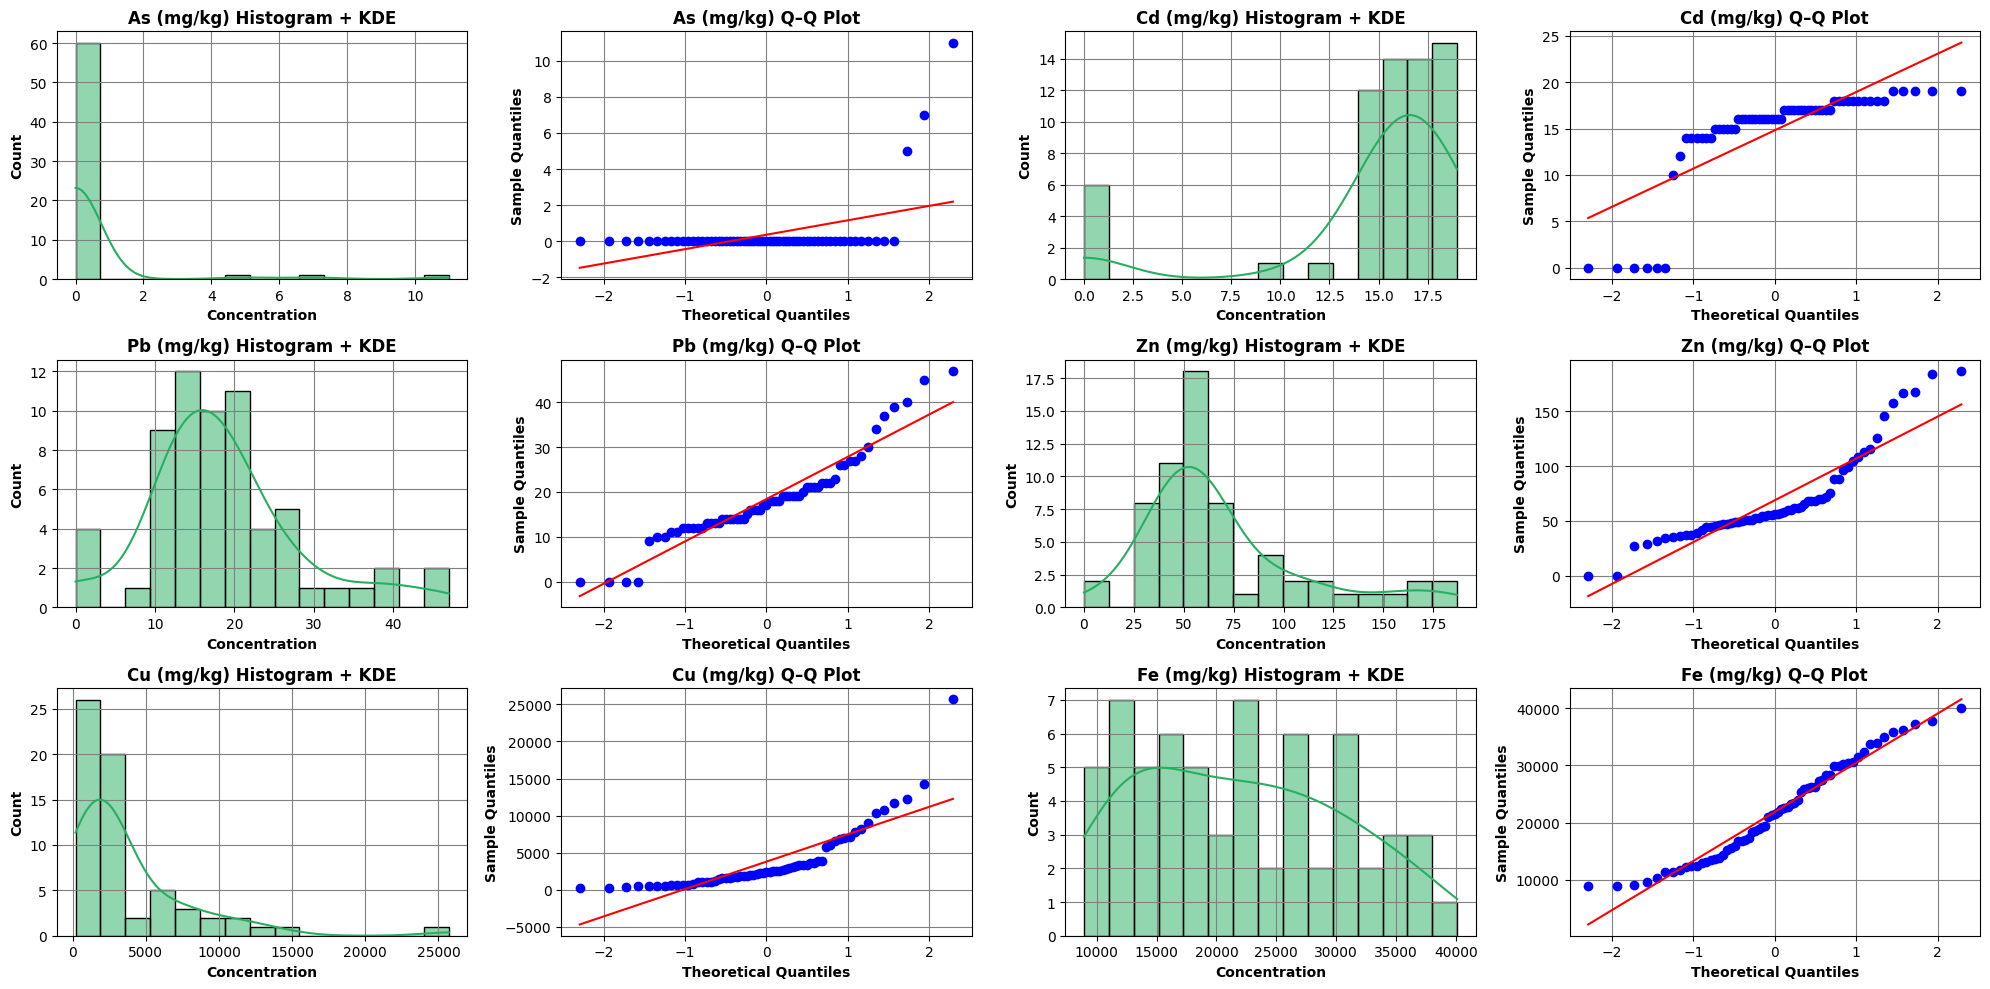

In [7]:
from scipy.stats import probplot

# Columns to plot 
columns_to_analyze = ['As (mg/kg)', 'Cd (mg/kg)', 'Pb (mg/kg)', 'Zn (mg/kg)', 'Cu (mg/kg)', 'Fe (mg/kg)']

# Create 3x4 grid (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 10))  # adjust size as needed
axes = axes.flatten()  # flatten for easy indexing

for i, element in enumerate(columns_to_analyze):
    if element in Topdf.columns:
        values = Topdf[element].dropna()
        
        # Histogram + KDE
        sns.histplot(values, bins=15, kde=True, color='#27AE60', edgecolor='black', ax=axes[2*i])
        axes[2*i].set_title(f'{element} Histogram + KDE', fontweight='semibold')
        axes[2*i].set_xlabel('Concentration', fontweight='semibold')
        axes[2*i].set_ylabel('Count', fontweight='semibold')
        axes[2*i].grid(True, color='gray')
        
        # Q-Q plot
        probplot(values, dist="norm", plot=axes[2*i + 1])
        axes[2*i + 1].set_title(f'{element} Q–Q Plot', fontweight='semibold')
        axes[2*i + 1].set_xlabel('Theoretical Quantiles', fontweight='semibold')
        axes[2*i + 1].set_ylabel('Sample Quantiles', fontweight='semibold')
        axes[2*i + 1].grid(True, color='gray')
        
    else:
        # Handle missing columns
        axes[2*i].text(0.5, 0.5, f"Column '{element}' not found", ha='center', va='center')
        axes[2*i].set_axis_off()
        axes[2*i + 1].set_visible(False)
        # x-axis tick labels
        axes[2*i + 1].tick_params(axis='x', colors='#000000', labelsize=15, width=1.2)  

        # y-axis tick labels
        axes[2*i + 1].tick_params(axis='y', colors='#2C3E50', labelsize=15, width=1.2)
        
# Hide any unused axes
for j in range(2*len(columns_to_analyze), 12):
    axes[j].set_visible(False)

plt.tight_layout()
### plt.suptitle('Histograms and Q–Q Plots of Top  surface Soil Elements', fontsize=16, y=1.02)
plt.savefig('Top_soil_his_q_q_plots.png', dpi=300, bbox_inches='tight')
plt.savefig('Top_soil_his_q_q_plots.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 2. Sub-surface

### 2.1. SubSoil Properties

In [ ]:
Subdf.info()

In [8]:
Subdf = Subdf.rename(columns={'0.01M CaCl2 (pH)': 'pH'}) # rename the pH column

# Specify which columns (Soil properties) to analyze
columns_to_analyze = ['pH', 'OM']

# Prepare list for table
table_rows = []

for soilproperty in columns_to_analyze:
    if soilproperty in Subdf.columns:
        values = Subdf[soilproperty].dropna()  # remove missing values if any
        W, p = shapiro(values)
        sk = skew(values, bias=False)
        kt = kurtosis(values, fisher=False, bias=False)
        if (abs(sk) <= 1) and (2 <= kt <= 4):
            distribution_shape = "Approximately normal (by skewness/kurtosis)"
        else:
            distribution_shape = "Non-normal (by skewness/kurtosis)"

        interpretation = "Not significantly different from normal" if p >= 0.05 else "Not normally distributed"
        
        table_rows.append({
            "Element": soilproperty,
            "Shapiro–Wilk W": round(W, 3),
            "p-value": "<0.001" if p < 0.001 else round(p, 3),
            "Skewness": round(sk, 2),
            "Kurtosis": round(kt, 2),
            "Normality Interpretation": interpretation,
        })
    else:
        print(f"Warning: Column '{soilproperty}' not found in file.")

# Create DataFrame
df_spS = pd.DataFrame(table_rows)

# Display table
print("Markdown Table:\n")
print(df_spS.to_markdown(index=False))

print("\nLaTeX Table:\n")
print(df_spS.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))

Markdown Table:

| Element   |   Shapiro–Wilk W |   p-value |   Skewness |   Kurtosis | Normality Interpretation                |
|:----------|-----------------:|----------:|-----------:|-----------:|:----------------------------------------|
| pH        |            0.974 |     0.485 |       0.35 |       2.69 | Not significantly different from normal |
| OM        |            0.89  |     0.001 |       1.27 |       4.68 | Not normally distributed                |

LaTeX Table:

\begin{table}
\centering
\caption{Shapiro–Wilk test results for selected elements}
\label{tab:shapiro_results}
\begin{tabular}{lrrrrl}
\toprule
Element &  Shapiro–Wilk W &  p-value &  Skewness &  Kurtosis &                Normality Interpretation \\
\midrule
     pH &           0.974 &    0.485 &      0.35 &      2.69 & Not significantly different from normal \\
     OM &           0.890 &    0.001 &      1.27 &      4.68 &                Not normally distributed \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_9838/2065225301.py:41: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_spS.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))


### 2.2. Subsoil PTEs

In [9]:
# Specify which columns (elements) to analyze
columns_to_analyze = ['As (mg/kg)', 'Cd (mg/kg)', 'Pb (mg/kg)', 'Zn (mg/kg)', 'Cu (mg/kg)', 'Fe (mg/kg)']

# Prepare list for table
table_rows = []

for element in columns_to_analyze:
    if element in Subdf.columns:
        values = Subdf[element].dropna()  # remove missing values
        W, p = shapiro(values)
        sk = skew(values, bias=False)
        kt = kurtosis(values, fisher=False, bias=False)
        if (abs(sk) <= 1) and (2 <= kt <= 4):
            distribution_shape = "Approximately normal (by skewness/kurtosis)"
        else:
            distribution_shape = "Non-normal (by skewness/kurtosis)"
        interpretation = "Not significantly different from normal" if p >= 0.05 else "Not normally distributed"
        
        table_rows.append({
            "Element": element,
            "Shapiro–Wilk W": round(W, 3),
            "p-value": "<0.001" if p < 0.001 else round(p, 3),
            "Skewness": round(sk, 2),
            "Kurtosis": round(kt, 2),
            "Normality Interpretation": interpretation,
        })
    else:
        print(f"Warning: Column '{element}' not found in file.")

# Create DataFrame
df_resultsS = pd.DataFrame(table_rows)

# Display table
print("Markdown Table:\n")
print(df_resultsS.to_markdown(index=False))

print("\nLaTeX Table:\n")
print(df_resultsS.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))

Markdown Table:

| Element    |   Shapiro–Wilk W | p-value   |   Skewness |   Kurtosis | Normality Interpretation                |
|:-----------|-----------------:|:----------|-----------:|-----------:|:----------------------------------------|
| As (mg/kg) |            0.361 | <0.001    |       2.88 |       9.95 | Not normally distributed                |
| Cd (mg/kg) |            0.587 | <0.001    |      -2.76 |      10.11 | Not normally distributed                |
| Pb (mg/kg) |            0.908 | 0.004     |      -0.66 |       3.45 | Not normally distributed                |
| Zn (mg/kg) |            0.931 | 0.02      |       0.72 |       4.79 | Not normally distributed                |
| Cu (mg/kg) |            0.633 | <0.001    |       2.76 |      11.19 | Not normally distributed                |
| Fe (mg/kg) |            0.968 | 0.326     |      -0.14 |       2.03 | Not significantly different from normal |

LaTeX Table:

\begin{table}
\centering
\caption{Shapiro–Wilk test resu

/tmp/ipykernel_9838/556270737.py:38: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_resultsS.to_latex(index=False, caption="Shapiro–Wilk test results for selected elements", label="tab:shapiro_results"))


### 2.3. Distribution and normality assessment of Subsoil PTEs concentrations using histograms, KDE curves, and Q–Q plots

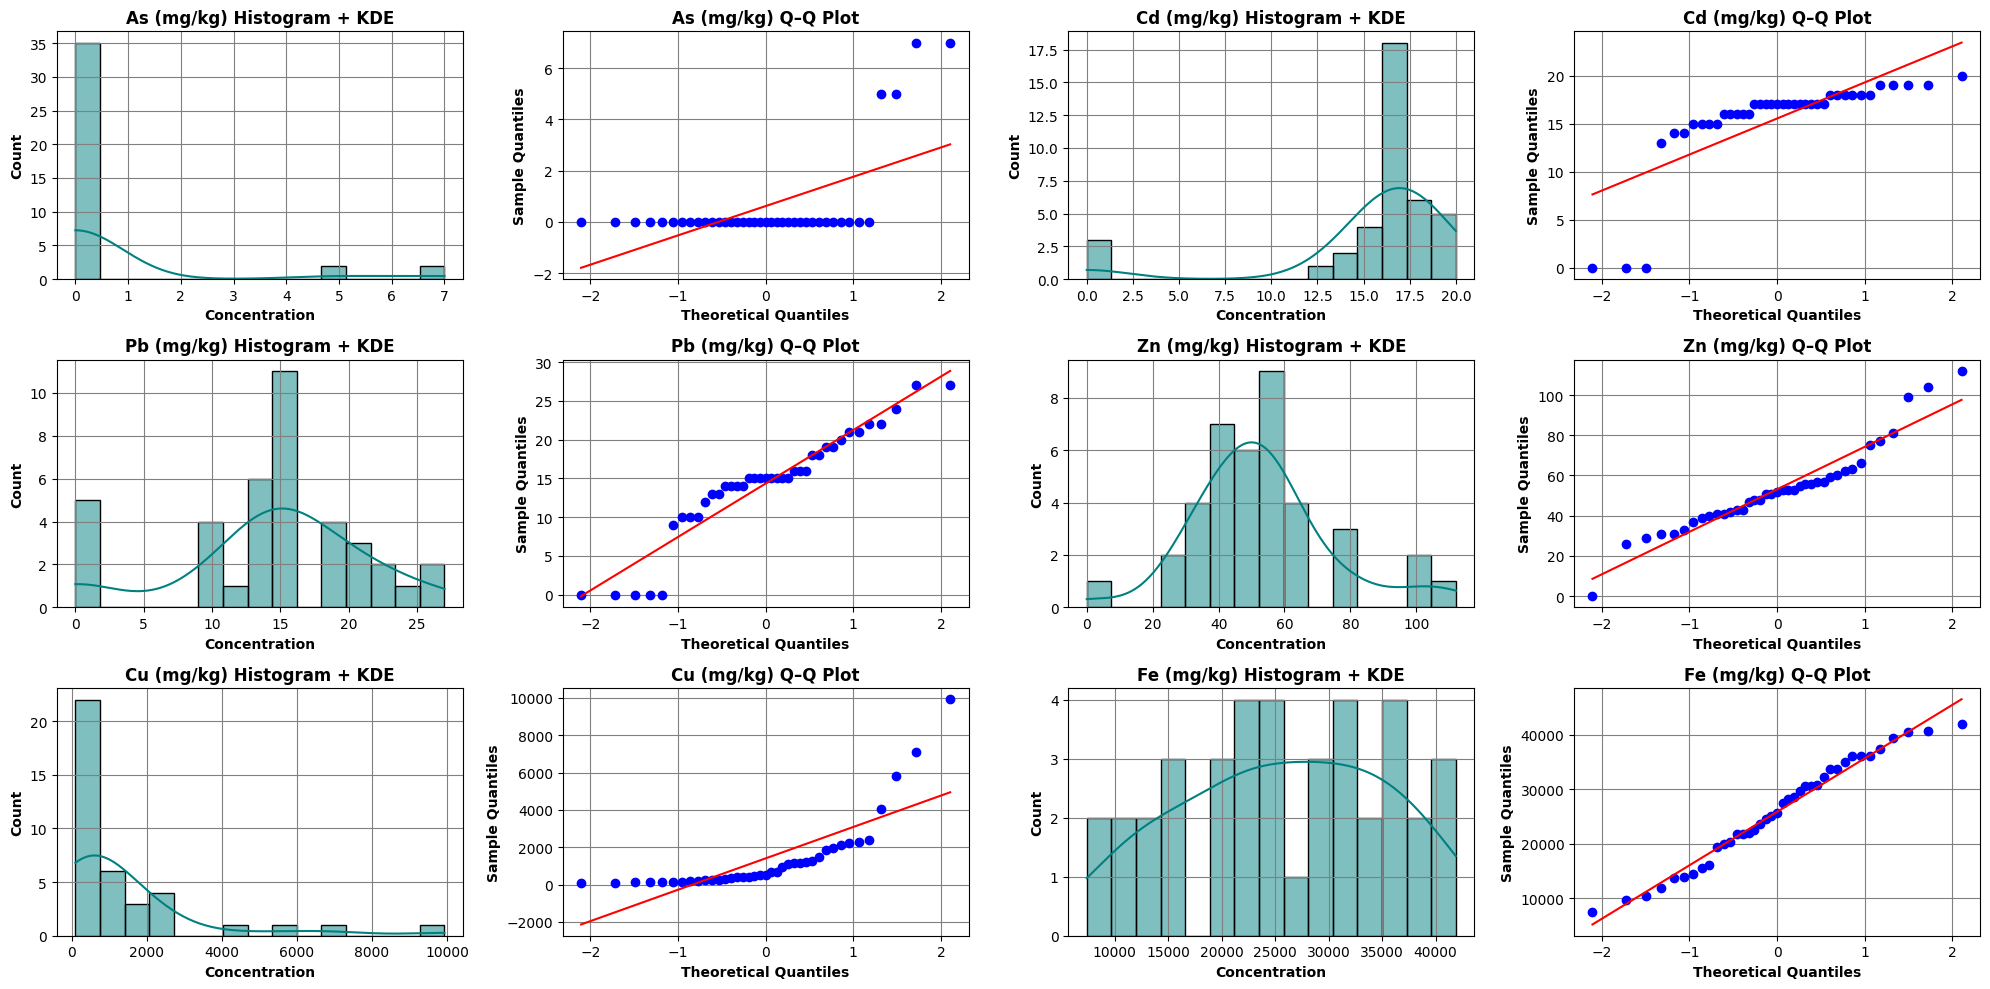

In [10]:
# Columns to plot (up to 6 elements for 3x4 grid)
columns_to_analyze = ['As (mg/kg)', 'Cd (mg/kg)', 'Pb (mg/kg)', 'Zn (mg/kg)', 'Cu (mg/kg)', 'Fe (mg/kg)']  # modify as needed

# Create 3x4 grid (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 10))  # adjust size as needed
axes = axes.flatten()  # flatten for easy indexing

for i, element in enumerate(columns_to_analyze):
    if element in Subdf.columns:
        values = Subdf[element].dropna()
        
        # Histogram + KDE
        sns.histplot(values, bins=15, kde=True, color='Teal', edgecolor='black', ax=axes[2*i])
        axes[2*i].set_title(f'{element} Histogram + KDE', fontweight='semibold')
        axes[2*i].set_xlabel('Concentration', fontweight='semibold')
        axes[2*i].set_ylabel('Count', fontweight='semibold')
        axes[2*i].grid(True, color='gray')
        
        # Q-Q plot
        probplot(values, dist="norm", plot=axes[2*i + 1])
        axes[2*i + 1].set_title(f'{element} Q–Q Plot', fontweight='semibold')
        axes[2*i + 1].set_xlabel('Theoretical Quantiles', fontweight='semibold')
        axes[2*i + 1].set_ylabel('Sample Quantiles', fontweight='semibold')
        axes[2*i + 1].grid(True, color='gray')
        
    else:
        # Handle missing columns
        axes[2*i].text(0.5, 0.5, f"Column '{element}' not found", ha='center', va='center')
        axes[2*i].set_axis_off()
        axes[2*i + 1].set_visible(False)
        # x-axis tick labels
        axes[2*i + 1].tick_params(axis='x', colors='#000000', labelsize=15, width=1.2)  

        # y-axis tick labels
        axes[2*i + 1].tick_params(axis='y', colors='#2C3E50', labelsize=15, width=1.2)
        
# Hide any unused axes
for j in range(2*len(columns_to_analyze), 12):
    axes[j].set_visible(False)

plt.tight_layout()
### plt.suptitle('Histograms and Q–Q Plots of Top  surface Soil Elements', fontsize=16, y=1.02)
plt.savefig('Sub_soil_his_q_q_plots.png', dpi=300, bbox_inches='tight')
plt.savefig('Sub_soil_his_q_q_plots.pdf', dpi=300, bbox_inches='tight')
plt.show()